In [1]:
import os, sys
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import json 

def find_root_path(path:str, word:str):
    parts = path.split(word, 1)    
    return parts[0] + word if len(parts) > 1 else path 
root_folder = find_root_path(os.path.abspath(os.getcwd()), 'art_lang')
sys.path.append(root_folder)

from rpod.optimization.parameters import dim_koz, tvec_sec, period
from rpod.dynamics.dynamics_trans import propagate_ct, roe_to_rtn, cim_roe
from rpod.optimization.utils import *

%load_ext autoreload
%autoreload 2

In [2]:
dir_name = 'v08'
module_path = root_folder + '/rpod/dataset/torch/' + dir_name 
data_param = np.load(module_path + '/dataset-rpod-param.npz', allow_pickle=True)
rtn_cvx = torch.load(module_path + '/torch_states_rtn_cvx.pth').numpy()  
rtn_scp = torch.load(module_path + '/torch_states_rtn_scp.pth').numpy()    
roe_cvx = torch.load(module_path + '/torch_states_roe_cvx.pth').numpy()
roe_scp = torch.load(module_path + '/torch_states_roe_scp.pth').numpy()
a_cvx = torch.load(module_path + '/torch_actions_cvx.pth').numpy()
a_scp = torch.load(module_path + '/torch_actions_scp.pth').numpy()

behav = data_param['behavior']
oe = data_param["oe"]
wyp = data_param["waypoints"]
wyp_times = data_param["waypoint_times"]  

In [3]:
# practice: open json (command summary) and get the command 
# This is needed during the training 
data_param['behavior'], data_param['command_id']

data = []
with open(root_folder+"/rpod/dataset/commands_summary_v5_train.jsonl", "r") as f:
    for line in f:
        data.append(json.loads(line))

data[0]['description'][data_param['command_id'][0]]

'Perform orbital maneuvers; approach the target and circumnavigate adhering to safety standards.'

In [4]:
# for the annotation file (filled with numbers) 
annotations = torch.load(module_path + '/annotation_texts.pth')
print(len(annotations))
rtn_cvx.shape


49441


(49441, 50, 6)

### CTG distribution for each behavior 

Behavior 0... feas: 8050 / 13335
Behavior 1... feas: 10083 / 13516
Behavior 2... feas: 6965 / 13144
Behavior 3... feas: 10818 / 13332
Behavior 4... feas: 6668 / 13332
Behavior 5... feas: 6857 / 13341
Behavior 6... feas: 0 / 0


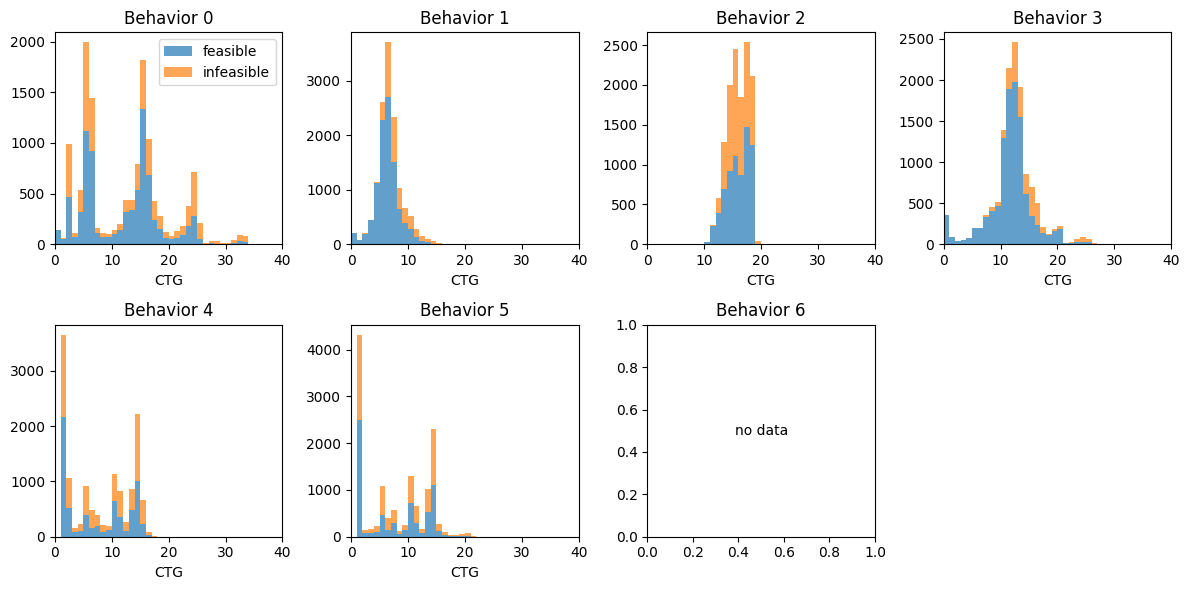

In [5]:
behavior_mode_full = data_param['behavior_full']
ctg_cvx_full = data_param['ctg_all'].flatten()
i_infeas = data_param['i_unfeas']
bins = np.arange(0, 50, 1)  # fixed bins for better comparison

fig = plt.figure(figsize=(12,6))

for j in range(7):
    mask_j       = (behavior_mode_full == j)
    mask_infeas  = np.zeros_like(behavior_mode_full, dtype=bool)
    mask_infeas[np.asarray(i_infeas, dtype=int)] = True

    mask_feas_j     = mask_j & ~mask_infeas
    mask_infeas_j   = mask_j &  mask_infeas

    x0 = np.ravel(np.asarray(ctg_cvx_full[mask_feas_j],   dtype=float))  # feasible
    x1 = np.ravel(np.asarray(ctg_cvx_full[mask_infeas_j], dtype=float))  # infeasible

    # drop NaN/Inf to avoid histogram errors
    x0 = x0[np.isfinite(x0)]
    x1 = x1[np.isfinite(x1)]
    print(f'Behavior {j}... feas: {np.sum(mask_feas_j)} / {np.sum(mask_j)}')

    ax_j = fig.add_subplot(2, 4, j+1)

    if x0.size + x1.size == 0:
        ax_j.set_title(f'Behavior {j}')
        ax_j.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax_j.transAxes)
        continue

    ax_j.hist([x0, x1], bins=bins, stacked=True, alpha=0.7, label=['feasible', 'infeasible'])
    ax_j.set_title(f'Behavior {j}')
    if j == 0:
        ax_j.legend()
    ax_j.set_xlim([0, 40])
    # ax_j.set_ylim([0, 30])
    ax_j.set_xlabel('CTG')

fig.tight_layout()    

Behavior 0... n_data: 8050
Behavior 1... n_data: 10083
Behavior 2... n_data: 6965
Behavior 3... n_data: 10818
Behavior 4... n_data: 6668
Behavior 5... n_data: 6857
Behavior 6... n_data: 0


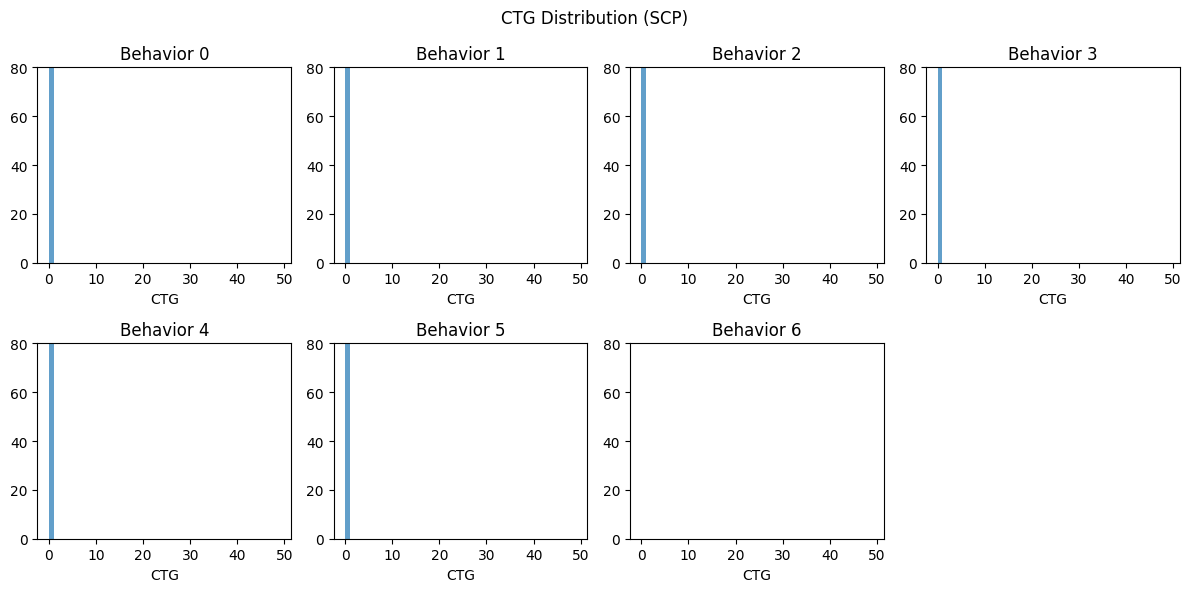

In [6]:
# sanity check: CTG of the SCP solution (should be all ZERO!) 

ctg_scp = torch.load(module_path + '/torch_ctgs_scp.pth').numpy()

fig = plt.figure(figsize=(12,6))
for j in range(7): 
    ax_j = fig.add_subplot(2, 4, j+1)
    mask_j = (behav == j)
    print(f'Behavior {j}... n_data: {np.sum(mask_j)}')

    ctg_scp_j = ctg_scp[mask_j, 0].flatten()
    ax_j.hist(ctg_scp_j, bins=bins, alpha=0.7)
    ax_j.set_title(f'Behavior {j}')
    # ax_j.set_xlim([0, 50])
    # ax_j.set_ylim([0, 30])
    ax_j.set_xlabel('CTG')
    ax_j.set_ylim([0,80])

fig.suptitle('CTG Distribution (SCP)')
fig.tight_layout()


100.0
Behavior 0... SCP feas: 8050
Behavior 1... SCP feas: 10083
Behavior 2... SCP feas: 6965


/tmp/ipykernel_200845/2110439756.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_j.legend()


Behavior 3... SCP feas: 10818
Behavior 4... SCP feas: 6668
Behavior 5... SCP feas: 6857
Behavior 6... SCP feas: 0


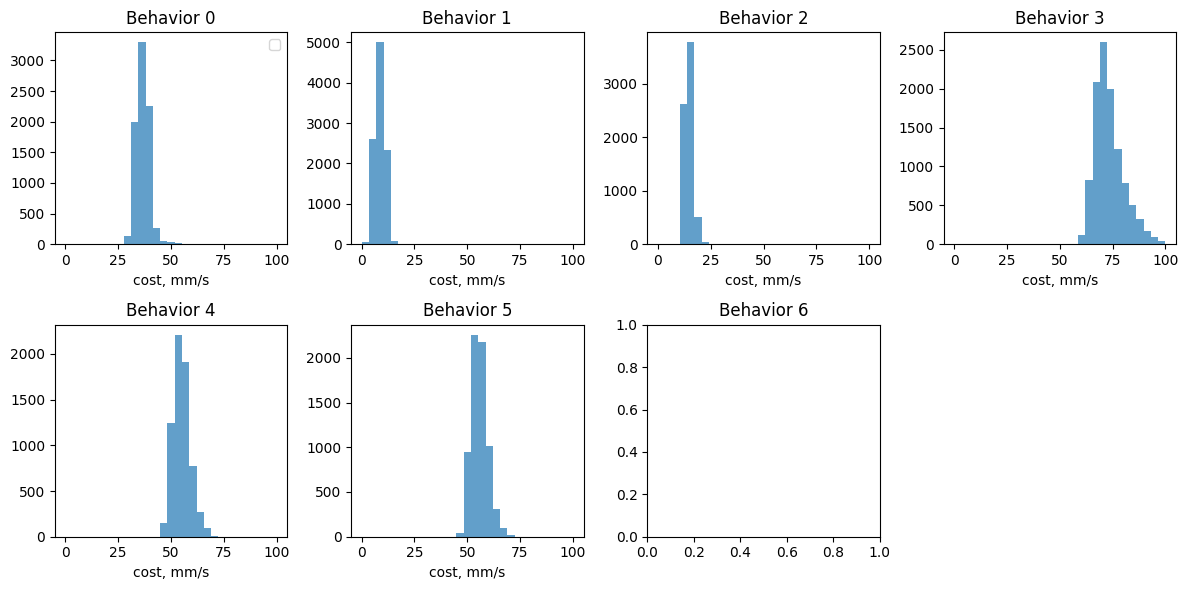

In [7]:
rtg_scp = -torch.load(module_path + '/torch_rtgs_scp.pth')
rtg_scp *= 1000  # mm/s 
rtg_max = np.minimum(np.max(rtg_scp.numpy()), 100)  # mm/s
print(rtg_max)
bins = np.linspace(0, rtg_max, 30)  # fixed bins for better comparison

fig = plt.figure(figsize=(12,6))

for j in range(7):
    
    mask_j = (behav == j)
    rtg_scp_j = np.asarray(rtg_scp[mask_j, 0], dtype=float)
    
    print(f'Behavior {j}... SCP feas: {np.sum(mask_j)}')

    ax_j = fig.add_subplot(2, 4, j+1)

    if rtg_scp_j.size == 0:
        ax_j.set_title(f'Behavior {j}')
        continue

    ax_j.hist(rtg_scp_j,  alpha=0.7, bins = bins)
    ax_j.set_title(f'Behavior {j}')
    if j == 0:
        ax_j.legend()
    # ax_j.set_xlim([0, 50])
    # ax_j.set_ylim([0, 30])
    ax_j.set_xlabel('cost, mm/s')

fig.tight_layout()    

### Plotting 3d data 

Behavior 0 : 8050 samples
Behavior 1 : 10083 samples
Behavior 2 : 6965 samples
Behavior 3 : 10818 samples
Behavior 4 : 6668 samples
Behavior 5 : 6857 samples


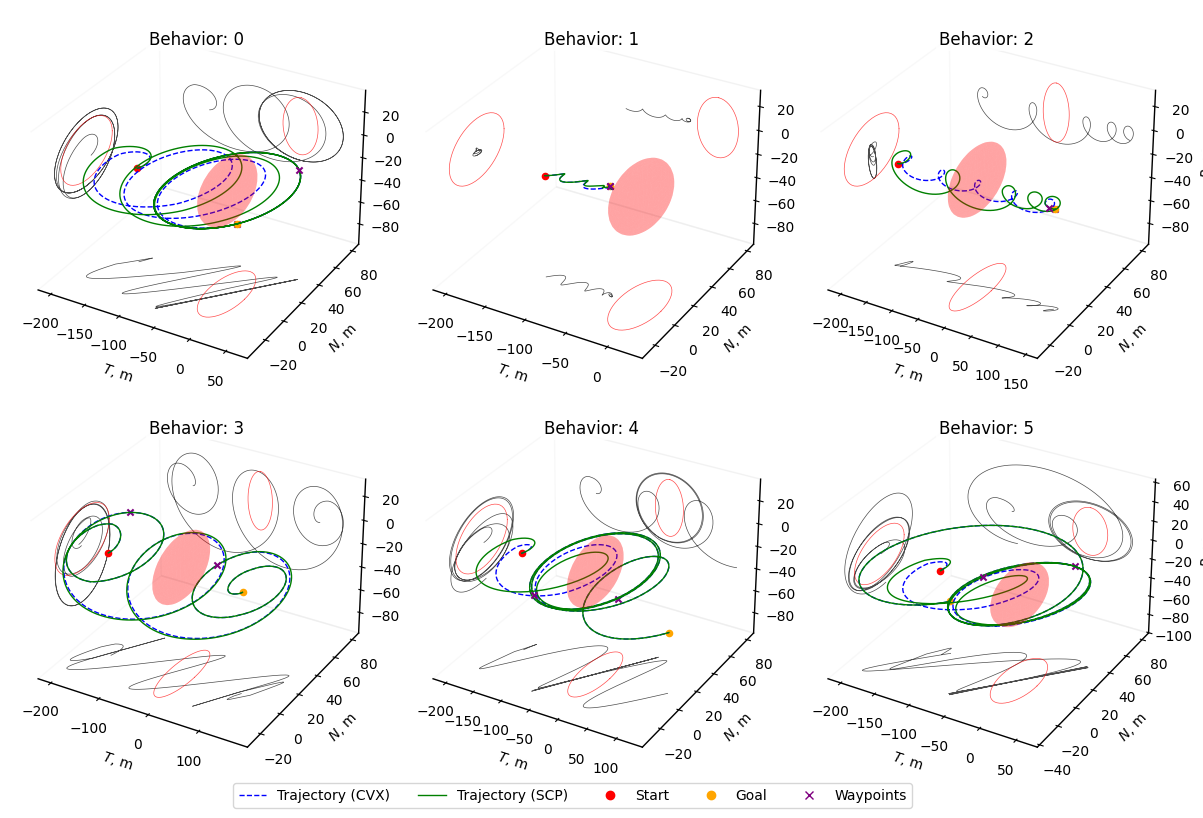

In [8]:
from matplotlib.lines import Line2D

phi = np.linspace(0, 2*np.pi, 50)  # tune this to get a better resolution
x_circ = dim_koz[0,1] * np.sin(phi) 
y_circ = dim_koz[0,2] * np.cos(phi)

x_proj = -90; y_proj = -200; z_proj = 80

fig = plt.figure(figsize=(15,10))

for i in range(6): 
    
    print(f'Behavior {i} : {np.sum(behav==i)} samples')
    
    # collect samples
    rtn_cvx_i = rtn_cvx[behav==i]
    rtn_scp_i = rtn_scp[behav==i]    
    roe_cvx_i = roe_cvx[behav==i]
    roe_scp_i = roe_scp[behav==i]
    a_cvx_i   = a_cvx[behav==i]
    a_scp_i   = a_scp[behav==i]
    oe_i = oe[behav==i]
    wyp_i = wyp[behav==i]
    wyp_times_i = wyp_times[behav==i]
        
    ax_i = fig.add_subplot(2, 3, i+1, projection='3d')
    
    ax_i.set_facecolor('white')
    ax_i.grid(False)
    for axis in [ax_i.xaxis, ax_i.yaxis, ax_i.zaxis]:
        axis.pane.fill = False
        axis.line.set_color('black')
        axis.line.set_linewidth(1)  # increase thickness
    
    for j in range(np.min([rtn_scp_i.shape[0], 1])): 

        _, roe_cvx_ct_ij, rtn_cvx_ct_ij = propagate_ct(roe_cvx_i[j], a_cvx_i[j], oe_i[j], tvec_sec, n=10)
        _, roe_scp_ct_ij, rtn_scp_ct_ij = propagate_ct(roe_scp_i[j], a_scp_i[j], oe_i[j], tvec_sec, n=10)

        x_cvx, y_cvx, z_cvx = rtn_cvx_ct_ij[:,0], rtn_cvx_ct_ij[:,1], rtn_cvx_ct_ij[:,2]
        x_scp, y_scp, z_scp = rtn_scp_ct_ij[:,0], rtn_scp_ct_ij[:,1], rtn_scp_ct_ij[:,2]

        # x_cvx, y_cvx, z_cvx = rtn_cvx_i[i, :,0], rtn_cvx_i[i, :,1], rtn_cvx_i[i, :,2]
        # x_scp, y_scp, z_scp = rtn_scp_i[j,:,0], rtn_scp_i[j,:,1], rtn_scp_i[j,:,2]

        # plot trajectories (discrete-time)
        ax_i.plot(y_cvx, z_cvx, x_cvx, 'b--', linewidth=1, zorder=5)
        ax_i.plot(y_scp, z_scp, x_scp, 'g-', linewidth=1, zorder=5)

        # scatter waypoints
        for k in range(1, wyp_i.shape[1]-2):
            wyp_rtn_i = roe_to_rtn(wyp_i[j, k], oe_i[j, wyp_times_i[j, k]])
            ax_i.scatter([wyp_rtn_i[1]], [wyp_rtn_i[2]], [wyp_rtn_i[0]], c='purple', marker='x', s=20, zorder=6)

        # minimal "projection shadows" onto planes
        alpha = 0.7
        ax_i.plot(y_scp, z_scp, np.full_like(x_scp, x_proj), 'k-', alpha=alpha, linewidth=0.5)  # xy plane (RT)
        ax_i.plot(y_scp, np.full_like(z_scp, z_proj), x_scp, 'k-', alpha=alpha, linewidth=0.5)  # xz plane (RN)
        ax_i.plot(np.full_like(y_scp, y_proj), z_scp, x_scp, 'k-', alpha=alpha, linewidth=0.5)  # yz plane (TN)
        
        ax_i.scatter([y_cvx[0]], [z_cvx[0]], [x_cvx[0]], c='red', marker='o', s=20, zorder=10)
        ax_i.scatter([y_cvx[-1]], [z_cvx[-1]], [x_cvx[-1]], c='orange', marker='o', s=20, zorder=10)

    plot_ellipse(ax_i, np.array([dim_koz[0,1], dim_koz[0,2], dim_koz[0,0]]), pos=[0,0,0], Ndisc=20)
    # ax_i.scatter([0], [0], [0], c='red', marker='o', s=8)

    # circle (kOZ) projection
    ax_i.plot(y_circ, x_circ, np.full_like(x_circ, x_proj), 'r-', alpha=alpha, linewidth=0.5)
    ax_i.plot(x_circ, np.full_like(x_circ, z_proj), y_circ, 'r-', alpha=alpha, linewidth=0.5)
    ax_i.plot(np.full_like(x_circ, y_proj), y_circ, x_circ, 'r-', alpha=alpha, linewidth=0.5)

    ax_i.set_xlabel('$T$, m')
    ax_i.set_ylabel('$N$, m')
    ax_i.set_zlabel('$R$, m')
    # ax_i.axis("equal")
        
    # t = ax_i.set_title(f'Behavior: {i}', pad=-30)
    # t.set_position([0.5, 0.60])   # slightly lower
    ax_i.text2D(
    0.5, 0.92, f'Behavior: {i}',   # tune (x,y)
    transform=ax_i.transAxes,
    ha='center', va='center',
    fontsize=12,
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=2.0)
)

legend_handles = [
    Line2D([], [], linestyle='--', color='b', linewidth=1, label='Trajectory (CVX)'),
    Line2D([], [], linestyle='-',  color='g', linewidth=1, label='Trajectory (SCP)'),
    Line2D([], [], marker='o', color='red',    linestyle='None', markersize=6, label='Start'),
    Line2D([], [], marker='o', color='orange', linestyle='None', markersize=6, label='Goal'),
    Line2D([], [], marker='x', color='purple', linestyle='None', markersize=6, label='Waypoints'),
]

fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=5,                 # one row
    frameon=True,
    bbox_to_anchor=(0.5, 0.07)  # push slightly below subplots
)

# fig.tight_layout()
plt.subplots_adjust(
    hspace=0.02,   # reduce vertical spacing
    wspace=0.06    # optional: tighten horizontal spacing too
)
plt.savefig('figures/dataset_behaviors.png', dpi=600, bbox_inches='tight', pad_inches=0.2)

[2.11876245e-07 5.00000815e-01 9.99999573e-01 3.00000002e+01
 7.99999928e-01 3.08000007e+01]
[-3.81920495e-09 -3.60000000e+01 -1.99999992e-01 -1.40000000e+00
 -5.99999999e-01  7.99999987e-01]
[ 2.04122635e-02  1.40993056e+02 -1.39864085e+00  6.62066079e+00
  5.99967025e-01  3.20031966e+00]
[  2.0605856  117.35757865   1.01071324   7.03136271  -1.96881338
   6.03647519]
[-11.90942704 111.25912484   2.09317379  24.94014292  -0.43794842
  30.29027577]
[ 6.93785781e+00 -1.14068968e+02  2.50323114e-02  4.14534683e+01
  1.57536899e+00  3.40999749e+01]


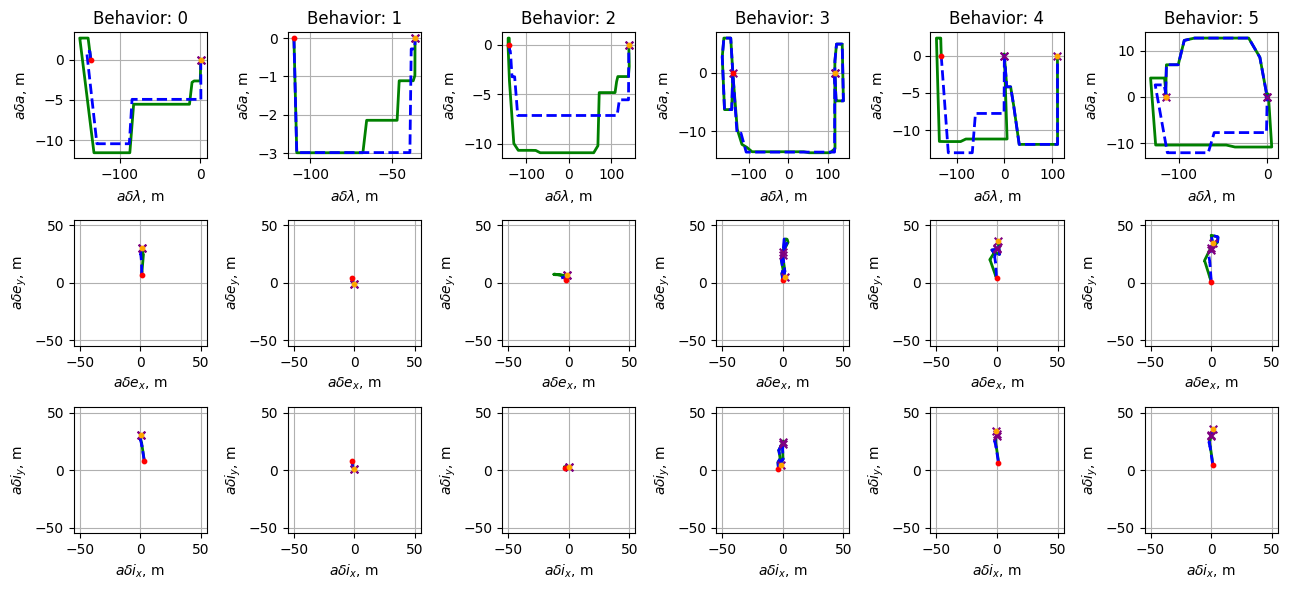

In [9]:
fs = 9
N_behavior = 6
lw = 2 

# ROE plot 
fig = plt.figure(figsize=(13,6))
for i in range(N_behavior):

    roe_cvx_i = roe_cvx[behav==i] 
    roe_scp_i = roe_scp[behav==i]   # convert to mm/s^2
    wyp_i = wyp[behav==i]
    wyp_times_i = wyp_times[behav==i]
    oe_i = oe[behav==i]
    a_scp_i   = a_scp[behav==i]
    a_cvx_i   = a_cvx[behav==i]

    axi1 = fig.add_subplot(3, N_behavior, i+1)
    axi2 = fig.add_subplot(3, N_behavior, i+1+N_behavior)
    axi3 = fig.add_subplot(3, N_behavior, i+1+N_behavior*2)
    
    for j in range(np.min([roe_scp_i.shape[0], 1])):
        
        
        print(roe_scp_i[j,-1])
        roe_art_ij = np.concatenate([roe_scp_i[j], [roe_scp_i[j,-1] + cim_roe(oe_i[j,-1]) @ a_scp_i[j,-1]]], axis=0)
        roe_cvx_ij = np.concatenate([roe_cvx_i[j], [roe_cvx_i[j,-1] + cim_roe(oe_i[j,-1]) @ a_cvx_i[j,-1]]], axis=0)
        
        axi1.plot(roe_art_ij[:,1], roe_art_ij[:,0], 'g-', linewidth=lw)
        axi2.plot(roe_art_ij[:,2], roe_art_ij[:,3], 'g-', linewidth=lw)
        axi3.plot(roe_art_ij[:,4], roe_art_ij[:,5], 'g-', linewidth=lw)

        axi1.plot(roe_cvx_ij[:,1], roe_cvx_ij[:,0], 'b--', linewidth=lw)
        axi2.plot(roe_cvx_ij[:,2], roe_cvx_ij[:,3], 'b--', linewidth=lw)
        axi3.plot(roe_cvx_ij[:,4], roe_cvx_ij[:,5], 'b--', linewidth=lw)

        axi1.scatter([roe_art_ij[0,1]], [roe_art_ij[0,0]], c='red', marker='o', s=10,zorder=5)
        axi1.scatter([roe_art_ij[-1,1]], [roe_art_ij[-1,0]], c='orange', marker='o', s=10,zorder=5)
        axi2.scatter([roe_art_ij[0,2]], [roe_art_ij[0,3]], c='red', marker='o', s=10,zorder=5)
        axi2.scatter([roe_art_ij[-1,2]], [roe_art_ij[-1,3]], c='orange', marker='o', s=10,zorder=5)
        axi3.scatter([roe_art_ij[0,4]], [roe_art_ij[0,5]], c='red', marker='o', s=10,zorder=5)
        axi3.scatter([roe_art_ij[-1,4]], [roe_art_ij[-1,5]], c='orange', marker='o', s=10,zorder=5)

        # waypoints 
        axi1.scatter([wyp_i[j,1:-1,1]], [wyp_i[j,1:-1,0]], c='purple', marker='x', s=30, zorder=4)
        axi2.scatter([wyp_i[j,1:-1,2]], [wyp_i[j,1:-1,3]], c='purple', marker='x', s=30, zorder=4)
        axi3.scatter([wyp_i[j,1:-1,4]], [wyp_i[j,1:-1,5]], c='purple', marker='x', s=30, zorder=4)

        # if i == 0 and j == 0:
        #     axi2.plot([],[], 'b-', label='roe (cvx)')
        #     axi2.plot([],[], 'g-', label='roe (art)')
        #     axi2.scatter([],[], c='red', marker='o', label='Start')
        #     axi2.scatter([],[], c='orange', marker='o', label='Goal')
        #     axi2.legend(fontsize=fs, loc='upper left')
    
    axi2.set_xlim([-55, 55]) 
    axi2.set_ylim([-55, 55]) 
    axi3.set_xlim([-55, 55])
    axi3.set_ylim([-55, 55])
    axi1.grid(True); axi2.grid(True); axi3.grid(True)
    # axi2.axis('equal')
    # axi3.axis('equal')

    axi1.set_xlabel('$a \delta \lambda$, m')
    axi1.set_ylabel('$a \delta a$, m')
    axi2.set_xlabel('$a \delta e_x$, m')
    axi2.set_ylabel('$a \delta e_y$, m')
    axi3.set_xlabel('$a \delta i_x$, m')
    axi3.set_ylabel('$a \delta i_y$, m')
    axi1.set_title(f'Behavior: {i}')
    
plt.tight_layout()
plt.savefig('figures/dataset_roe.png', dpi=600, bbox_inches='tight', pad_inches=0.5)

Text(0.5, 0.98, 'Behavior 0')

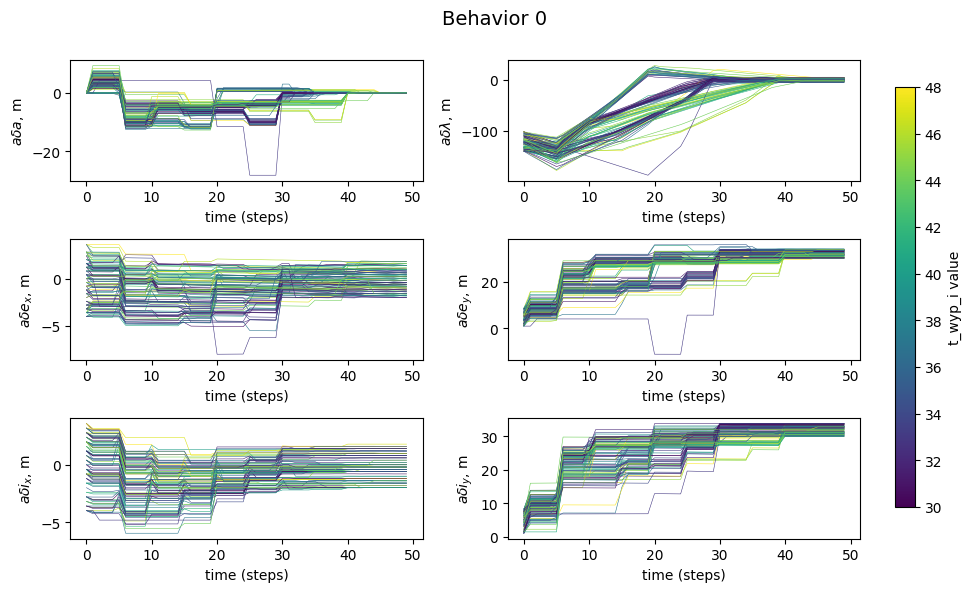

In [10]:
fs = 9
behav_id = 0
label = ['$a \delta a$, m', '$a \delta \lambda$, m', '$a \delta e_x$, m', '$a \delta e_y$, m', '$a \delta i_x$, m', '$a \delta i_y$, m']
# ROE time hisotry  
# t_orbit = np.concatenate((tvec_sec, [tvec_sec[-1]])) / period
t_orbit = tvec_sec / period  # IGNORE

roe_cvx_i = roe_cvx[behav==behav_id] 
roe_scp_i = roe_scp[behav==behav_id]   # convert to mm/s^2
wyp_i = wyp[behav==behav_id]
wyp_times_i = wyp_times[behav==behav_id]
oe_i = oe[behav==behav_id]
fig = plt.figure(figsize=(10,6))

t_wyp_i = wyp_times_i[:,1]
vmin, vmax = np.min(t_wyp_i), np.max(t_wyp_i)
cmap = plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
colors = cmap(norm(t_wyp_i))

for k in range(6):     
    ax = fig.add_subplot(3,2,k+1)
    for j in range(np.min([roe_scp_i.shape[0], 100])):
        ax.plot(roe_scp_i[j, :, k], color=colors[j], linewidth=0.4)
    ax.set_xlabel('time (steps)')
    ax.set_ylabel(label[k])
    
fig.tight_layout(rect=[0, 0, 0.88, 0.92])   # leave top 8% for title
cax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, cax=cax, label="t_wyp_i value")

fig.suptitle("Behavior 0", y=0.98, fontsize=14)



Text(0.5, 0.98, 'Behavior 1')

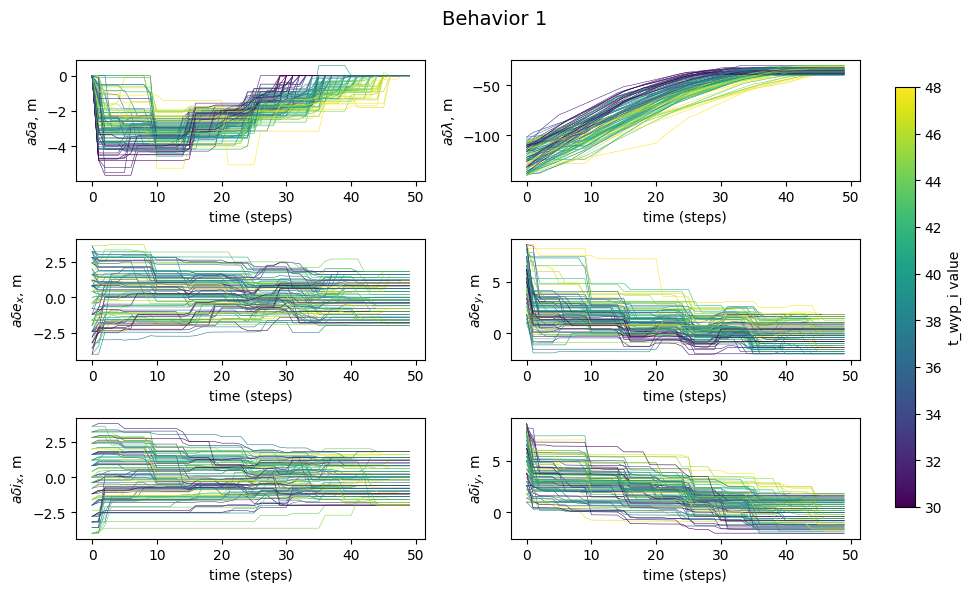

In [11]:
behav_id = 1
# ROE time hisotry  
# t_orbit = np.concatenate((tvec_sec, [tvec_sec[-1]])) / period
t_orbit = tvec_sec / period  # IGNORE

roe_cvx_i = roe_cvx[behav==behav_id] 
roe_scp_i = roe_scp[behav==behav_id]   # convert to mm/s^2
wyp_i = wyp[behav==behav_id]
wyp_times_i = wyp_times[behav==behav_id]
oe_i = oe[behav==behav_id]
fig = plt.figure(figsize=(10,6))

t_wyp_i = wyp_times_i[:,1]
vmin, vmax = np.min(t_wyp_i), np.max(t_wyp_i)
cmap = plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
colors = cmap(norm(t_wyp_i))

for k in range(6):     
    ax = fig.add_subplot(3,2,k+1)
    for j in range(np.min([roe_scp_i.shape[0], 100])):
        ax.plot(roe_scp_i[j, :, k], color=colors[j], linewidth=0.4)
    ax.set_xlabel('time (steps)')
    ax.set_ylabel(label[k])
    
fig.tight_layout(rect=[0, 0, 0.88, 0.92])   # leave top 8% for title
cax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, cax=cax, label="t_wyp_i value")

fig.suptitle("Behavior 1", y=0.98, fontsize=14)


Text(0.5, 0.98, 'Behavior 2')

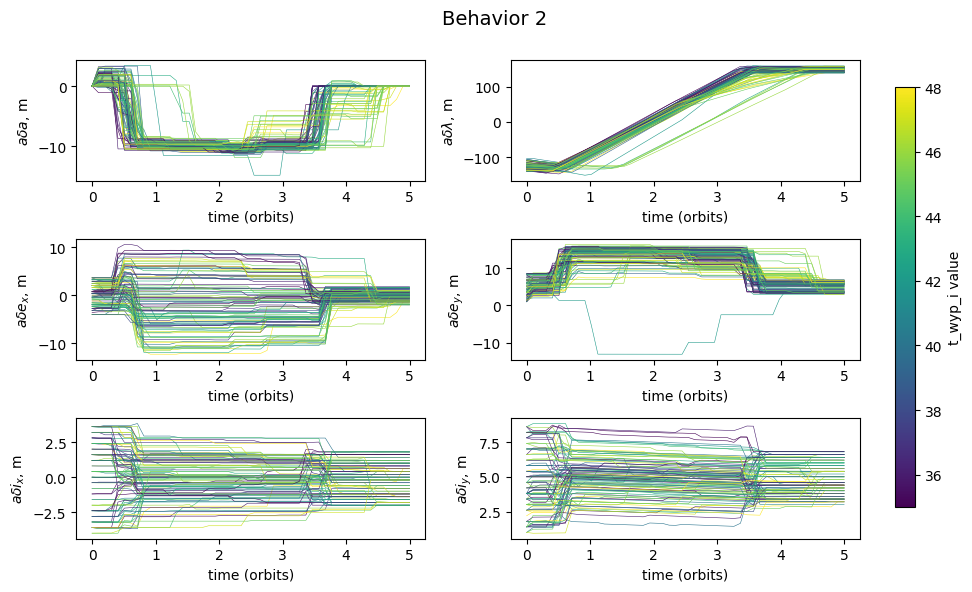

In [12]:
behav_id = 2
# ROE time hisotry  
# t_orbit = np.concatenate((tvec_sec, [tvec_sec[-1]])) / period
t_orbit = tvec_sec / period  # IGNORE

roe_cvx_i = roe_cvx[behav==behav_id] 
roe_scp_i = roe_scp[behav==behav_id]   # convert to mm/s^2
wyp_i = wyp[behav==behav_id]
wyp_times_i = wyp_times[behav==behav_id]
oe_i = oe[behav==behav_id]
fig = plt.figure(figsize=(10,6))

t_wyp_i = wyp_times_i[:,1]
vmin, vmax = np.min(t_wyp_i), np.max(t_wyp_i)
cmap = plt.get_cmap('viridis')
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
colors = cmap(norm(t_wyp_i))

for k in range(6):     
    ax = fig.add_subplot(3,2,k+1)
    for j in range(np.min([roe_scp_i.shape[0], 100])):
        ax.plot(t_orbit, roe_scp_i[j, :, k], color=colors[j], linewidth=0.4)
    ax.set_xlabel('time (orbits)')
    ax.set_ylabel(label[k])
    
    
fig.tight_layout(rect=[0, 0, 0.88, 0.92])   # leave top 8% for title
cax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
fig.colorbar(sm, cax=cax, label="t_wyp_i value")

fig.suptitle("Behavior 2", y=0.98, fontsize=14)

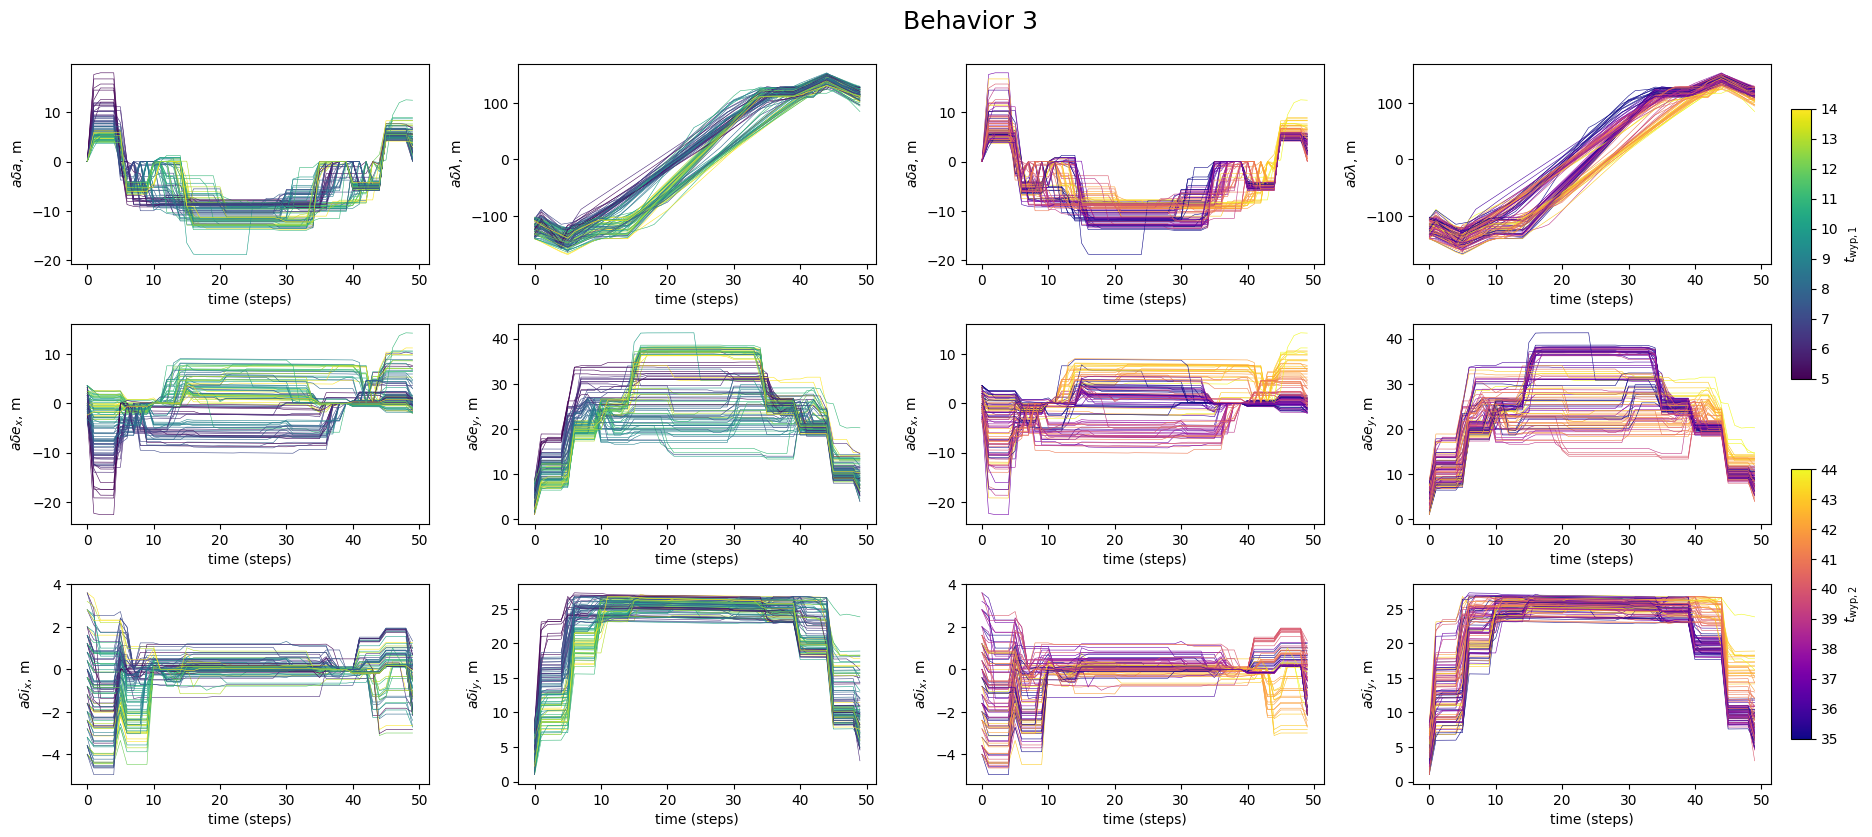

In [13]:
behav_id = 3
t_orbit = tvec_sec / period

roe_scp_i   = roe_scp[behav == behav_id]
wyp_times_i = wyp_times[behav == behav_id]

t_wyp_i = wyp_times_i[:, 1]   # left color
w_wyp_i = wyp_times_i[:, 2]   # right color

N_traj = min(roe_scp_i.shape[0], 100, len(t_wyp_i), len(w_wyp_i))

cmap1 = plt.get_cmap("viridis")
cmap2 = plt.get_cmap("plasma")
norm_left  = mpl.colors.Normalize(vmin=t_wyp_i.min(), vmax=t_wyp_i.max())
norm_right = mpl.colors.Normalize(vmin=w_wyp_i.min(), vmax=w_wyp_i.max())
colors_left  = cmap1(norm_left(t_wyp_i))
colors_right = cmap2(norm_right(w_wyp_i))

# --------- FIGURE (NO constrained_layout) ---------
fig, axes = plt.subplots(3, 4, figsize=(20, 9))  # <-- important: no constrained_layout=True
axes_flat = axes.ravel()

# pack subplots but leave good space for title
fig.subplots_adjust(
    left=0.05,
    right=0.90,   # room for colorbars
    bottom=0.10,
    top=0.9,     # <--- shrink subplot region to make room for title
    wspace=0.25,
    hspace=0.30,
)

# --------- LEFT 3×2 (cols 0–1) colored by t_wyp_i ---------
k_left = [0,1,4,5,8,9]
for (l,k) in enumerate(k_left):
    ax = axes_flat[k]
    for j in range(N_traj):
        ax.plot(roe_scp_i[j, :, l], color=colors_left[j], linewidth=0.4)
    ax.set_xlabel("time (steps)")
    ax.set_ylabel(label[l])

# --------- RIGHT 3×2 (cols 2–3) colored by w_wyp_i ---------
k_right = [2,3,6,7,10,11]
for (l,k) in enumerate(k_right):
    ax = axes_flat[k]
    for j in range(N_traj):
        ax.plot(roe_scp_i[j, :, l], color=colors_right[j], linewidth=0.4)
    ax.set_xlabel("time (steps)")
    ax.set_ylabel(label[l])
# --------- TITLE WITH CLEAR SEPARATION ---------
fig.suptitle(f"Behavior {behav_id}", fontsize=18, y=0.96)

# --------- COLORBARS ON FAR RIGHT ---------
cax_left = fig.add_axes([0.91, 0.55, 0.01, 0.30])
sm_left  = mpl.cm.ScalarMappable(norm=norm_left, cmap=cmap1)
sm_left.set_array([])
fig.colorbar(sm_left, cax=cax_left, label=r"$t_{\mathrm{wyp},1}$")

cax_right = fig.add_axes([0.91, 0.15, 0.01, 0.30])
sm_right  = mpl.cm.ScalarMappable(norm=norm_right, cmap=cmap2)
sm_right.set_array([])
fig.colorbar(sm_right, cax=cax_right, label=r"$t_{\mathrm{wyp},2}$")



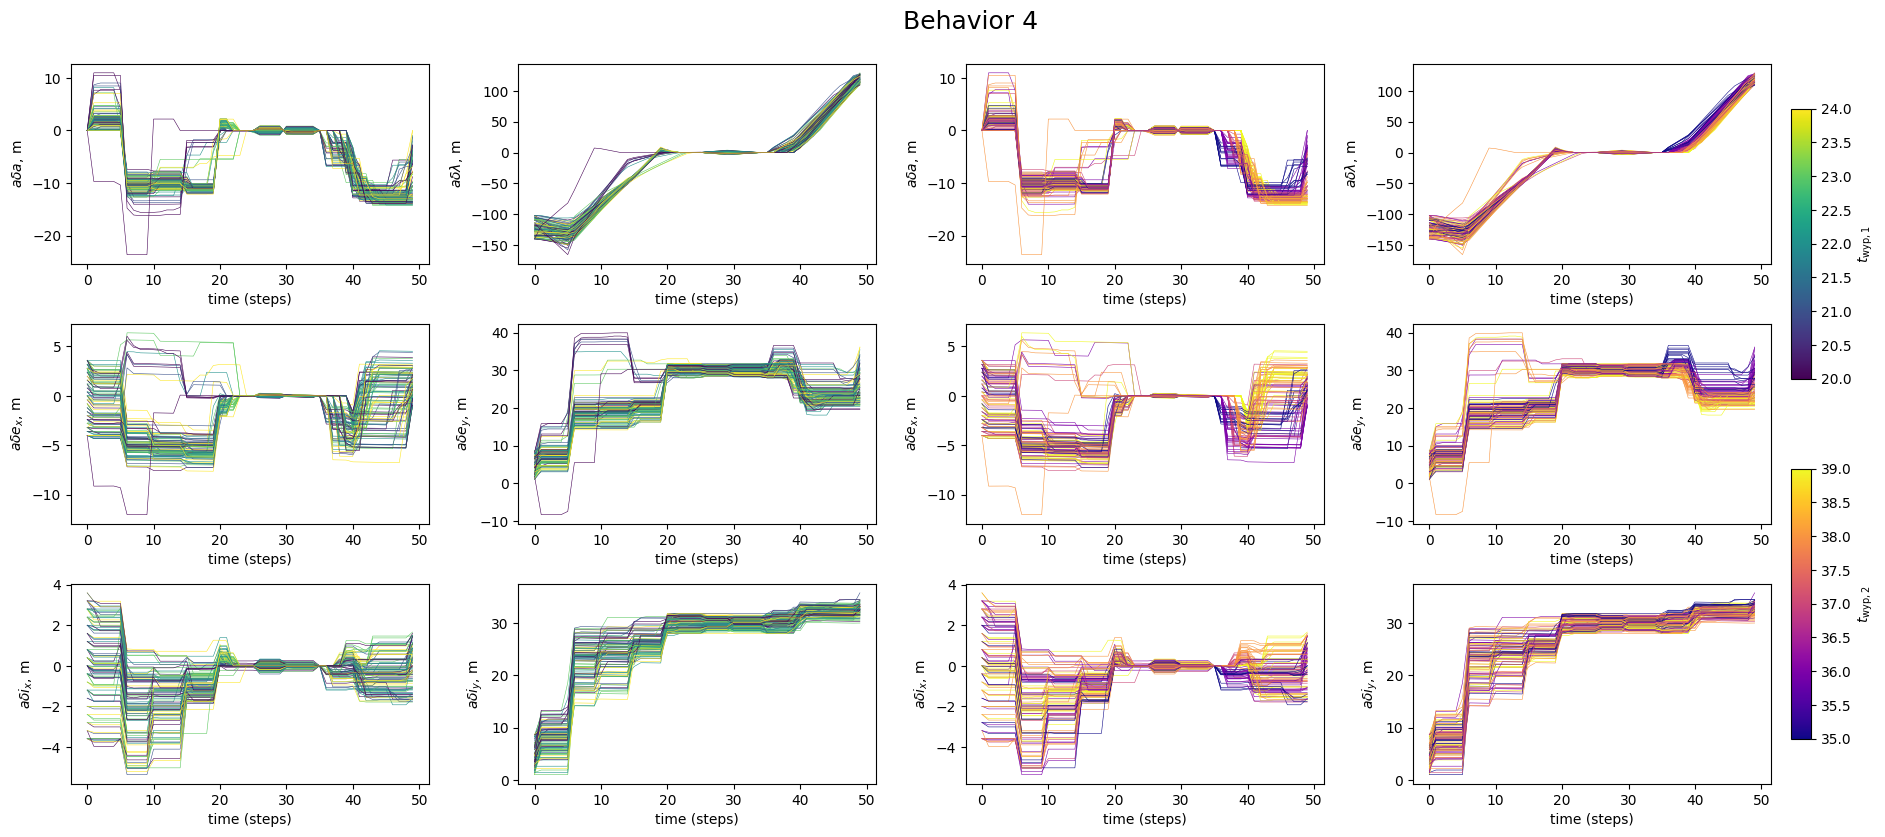

In [14]:
behav_id = 4
t_orbit = tvec_sec / period

roe_scp_i   = roe_scp[behav == behav_id]
wyp_times_i = wyp_times[behav == behav_id]

t_wyp_i = wyp_times_i[:, 1]   # left color
w_wyp_i = wyp_times_i[:, 2]   # right color

N_traj = min(roe_scp_i.shape[0], 100, len(t_wyp_i), len(w_wyp_i))

cmap1 = plt.get_cmap("viridis")
cmap2 = plt.get_cmap("plasma")
norm_left  = mpl.colors.Normalize(vmin=t_wyp_i.min(), vmax=t_wyp_i.max())
norm_right = mpl.colors.Normalize(vmin=w_wyp_i.min(), vmax=w_wyp_i.max())
colors_left  = cmap1(norm_left(t_wyp_i))
colors_right = cmap2(norm_right(w_wyp_i))

# --------- FIGURE (NO constrained_layout) ---------
fig, axes = plt.subplots(3, 4, figsize=(20, 9))  # <-- important: no constrained_layout=True
axes_flat = axes.ravel()

# pack subplots but leave good space for title
fig.subplots_adjust(
    left=0.05,
    right=0.90,   # room for colorbars
    bottom=0.10,
    top=0.9,     # <--- shrink subplot region to make room for title
    wspace=0.25,
    hspace=0.30,
)

# --------- LEFT 3×2 (cols 0–1) colored by t_wyp_i ---------
k_left = [0,1,4,5,8,9]
for (l,k) in enumerate(k_left):
    ax = axes_flat[k]
    for j in range(N_traj):
        ax.plot(roe_scp_i[j, :, l], color=colors_left[j], linewidth=0.4)
    ax.set_xlabel("time (steps)")
    ax.set_ylabel(label[l])

# --------- RIGHT 3×2 (cols 2–3) colored by w_wyp_i ---------
k_right = [2,3,6,7,10,11]
for (l,k) in enumerate(k_right):
    ax = axes_flat[k]
    for j in range(N_traj):
        ax.plot(roe_scp_i[j, :, l], color=colors_right[j], linewidth=0.4)
    ax.set_xlabel("time (steps)")
    ax.set_ylabel(label[l])
# --------- TITLE WITH CLEAR SEPARATION ---------
fig.suptitle(f"Behavior {behav_id}", fontsize=18, y=0.96)

# --------- COLORBARS ON FAR RIGHT ---------
cax_left = fig.add_axes([0.91, 0.55, 0.01, 0.30])
sm_left  = mpl.cm.ScalarMappable(norm=norm_left, cmap=cmap1)
sm_left.set_array([])
fig.colorbar(sm_left, cax=cax_left, label=r"$t_{\mathrm{wyp},1}$")

cax_right = fig.add_axes([0.91, 0.15, 0.01, 0.30])
sm_right  = mpl.cm.ScalarMappable(norm=norm_right, cmap=cmap2)
sm_right.set_array([])
fig.colorbar(sm_right, cax=cax_right, label=r"$t_{\mathrm{wyp},2}$")


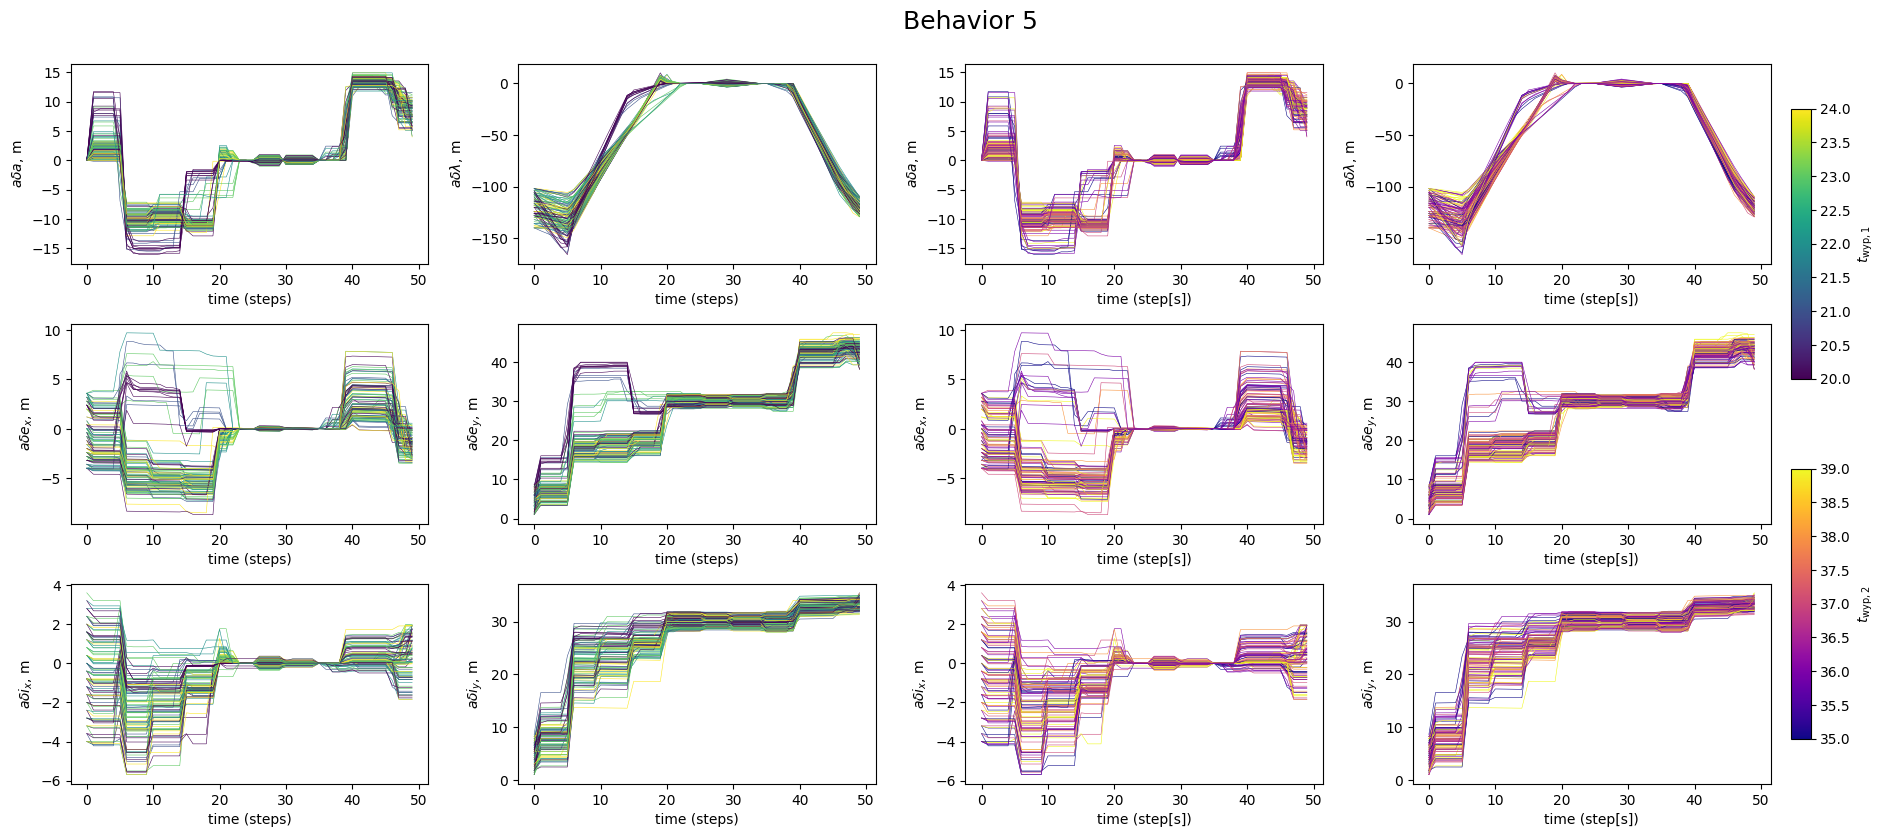

In [15]:
behav_id = 5
t_orbit = tvec_sec / period

roe_scp_i   = roe_scp[behav == behav_id]
wyp_times_i = wyp_times[behav == behav_id]

t_wyp_i = wyp_times_i[:, 1]   # left color
w_wyp_i = wyp_times_i[:, 2]   # right color

N_traj = min(roe_scp_i.shape[0], 100, len(t_wyp_i), len(w_wyp_i))

cmap1 = plt.get_cmap("viridis")
cmap2 = plt.get_cmap("plasma")
norm_left  = mpl.colors.Normalize(vmin=t_wyp_i.min(), vmax=t_wyp_i.max())
norm_right = mpl.colors.Normalize(vmin=w_wyp_i.min(), vmax=w_wyp_i.max())
colors_left  = cmap1(norm_left(t_wyp_i))
colors_right = cmap2(norm_right(w_wyp_i))

# --------- FIGURE (NO constrained_layout) ---------
fig, axes = plt.subplots(3, 4, figsize=(20, 9))  # <-- important: no constrained_layout=True
axes_flat = axes.ravel()

# pack subplots but leave good space for title
fig.subplots_adjust(
    left=0.05,
    right=0.90,   # room for colorbars
    bottom=0.10,
    top=0.9,     # <--- shrink subplot region to make room for title
    wspace=0.25,
    hspace=0.30,
)

# --------- LEFT 3×2 (cols 0–1) colored by t_wyp_i ---------
k_left = [0,1,4,5,8,9]
for (l,k) in enumerate(k_left):
    ax = axes_flat[k]
    for j in range(N_traj):
        ax.plot(roe_scp_i[j, :, l], color=colors_left[j], linewidth=0.4)
    ax.set_xlabel("time (steps)")
    ax.set_ylabel(label[l])

# --------- RIGHT 3×2 (cols 2–3) colored by w_wyp_i ---------
k_right = [2,3,6,7,10,11]
for (l,k) in enumerate(k_right):
    ax = axes_flat[k]
    for j in range(N_traj):
        ax.plot(roe_scp_i[j, :, l], color=colors_right[j], linewidth=0.4)
    ax.set_xlabel("time (step[s])")
    ax.set_ylabel(label[l])
# --------- TITLE WITH CLEAR SEPARATION ---------
fig.suptitle(f"Behavior {behav_id}", fontsize=18, y=0.96)

# --------- COLORBARS ON FAR RIGHT ---------
cax_left = fig.add_axes([0.91, 0.55, 0.01, 0.30])
sm_left  = mpl.cm.ScalarMappable(norm=norm_left, cmap=cmap1)
sm_left.set_array([])
fig.colorbar(sm_left, cax=cax_left, label=r"$t_{\mathrm{wyp},1}$")

cax_right = fig.add_axes([0.91, 0.15, 0.01, 0.30])
sm_right  = mpl.cm.ScalarMappable(norm=norm_right, cmap=cmap2)
sm_right.set_array([])
fig.colorbar(sm_right, cax=cax_right, label=r"$t_{\mathrm{wyp},2}$")


### animation (be careful this takes 15 mins) 

In [ ]:
from matplotlib.lines import Line2D
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np
import matplotlib.pyplot as plt

gif_path = "traj_animation_panel.gif"

n_beh = 6
n_per_behavior = 1

# KOZ circle (static)
phi = np.linspace(0, 2*np.pi, 50)
x_circ = dim_koz[0,1] * np.sin(phi)
y_circ = dim_koz[0,2] * np.cos(phi)

alpha = 0.7  # match your static figure

fig = plt.figure(figsize=(15, 10))
axs = []
artists_per_axis = {}

# --- axes styling (match your final figure) ---
for i in range(n_beh):
    ax_i = fig.add_subplot(2, 3, i+1, projection='3d')
    ax_i.set_facecolor('white')
    ax_i.grid(False)
    for axis in [ax_i.xaxis, ax_i.yaxis, ax_i.zaxis]:
        axis.pane.fill = False
        axis.line.set_color('black')
        axis.line.set_linewidth(1)

    ax_i.set_xlabel('$T$, m')
    ax_i.set_ylabel('$N$, m')
    ax_i.set_zlabel('$R$, m')

    # explicit "title" placement via text2D (same as your final)
    ax_i.text2D(
        0.5, 0.92, f'Behavior: {i}',
        transform=ax_i.transAxes,
        ha='center', va='center',
        fontsize=12,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=2.0)
    )

    axs.append(ax_i)

# --- figure-level legend (same style/location concept) ---
legend_handles = [
    Line2D([], [], linestyle='--', color='b', linewidth=1, label='Trajectory (CVX)'),
    Line2D([], [], linestyle='-',  color='g', linewidth=1, label='Trajectory (SCP)'),
    Line2D([], [], marker='o', color='red',    linestyle='None', markersize=6, label='Start'),
    Line2D([], [], marker='o', color='orange', linestyle='None', markersize=6, label='Goal'),
    Line2D([], [], marker='x', color='purple', linestyle='None', markersize=6, label='Waypoints'),
]
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=5,
    frameon=True,
    bbox_to_anchor=(0.5, 0.07)
)

# --- build artists per behavior ---
global_frames = None  # will set from first available trajectory length

for i in range(n_beh):
    idx_mask = (behav == i)

    rtn_scp_i     = rtn_scp[idx_mask]
    roe_cvx_i     = roe_cvx[idx_mask]
    roe_scp_i     = roe_scp[idx_mask]
    a_cvx_i       = a_cvx[idx_mask]
    a_scp_i       = a_scp[idx_mask]
    oe_i          = oe[idx_mask]
    wyp_i         = wyp[idx_mask] if "wyp" in globals() else None
    wyp_times_i   = wyp_times[idx_mask] if "wyp_times" in globals() else None

    ax_i = axs[i]

    # static elements (match your final)
    plot_ellipse(ax_i, np.array([dim_koz[0,1], dim_koz[0,2], dim_koz[0,0]]), pos=[0,0,0], Ndisc=20)

    # KOZ projections (red)
    ax_i.plot(y_circ, x_circ, np.full_like(x_circ, x_proj), 'r-', alpha=alpha, linewidth=0.5)
    ax_i.plot(x_circ, np.full_like(x_circ, z_proj), y_circ, 'r-', alpha=alpha, linewidth=0.5)
    ax_i.plot(np.full_like(x_circ, y_proj), y_circ, x_circ, 'r-', alpha=alpha, linewidth=0.5)

    art = {"cvx": [], "scp": [], "proj_xy": [], "proj_xz": [], "proj_yz": [], "wyp": []}

    n_samples = min(n_per_behavior, rtn_scp_i.shape[0]) if getattr(rtn_scp_i, "shape", None) and rtn_scp_i.shape[0] > 0 else 0

    for j in range(n_samples):
        # propagate (continuous-time) exactly as your static code
        _, _, rtn_cvx_ct_ij = propagate_ct(roe_cvx_i[j], a_cvx_i[j], oe_i[j], tvec_sec, n=10)
        _, _, rtn_scp_ct_ij = propagate_ct(roe_scp_i[j], a_scp_i[j], oe_i[j], tvec_sec, n=10)

        # NOTE: match your static extraction: rtn[:,0/1/2]
        x_cvx, y_cvx, z_cvx = rtn_cvx_ct_ij[:, 0], rtn_cvx_ct_ij[:, 1], rtn_cvx_ct_ij[:, 2]
        x_scp, y_scp, z_scp = rtn_scp_ct_ij[:, 0], rtn_scp_ct_ij[:, 1], rtn_scp_ct_ij[:, 2]

        if global_frames is None:
            global_frames = len(x_cvx)

        # main trajectories (match line styles: CVX b--, SCP g-)
        (cvx_line,) = ax_i.plot(y_cvx[:1], z_cvx[:1], x_cvx[:1], 'b--', linewidth=1, zorder=5)
        (scp_line,) = ax_i.plot(y_scp[:1], z_scp[:1], x_scp[:1], 'g-',  linewidth=1, zorder=5)

        # stash full arrays
        cvx_line._full_y, cvx_line._full_z, cvx_line._full_x = y_cvx, z_cvx, x_cvx
        scp_line._full_y, scp_line._full_z, scp_line._full_x = y_scp, z_scp, x_scp

        art["cvx"].append(cvx_line)
        art["scp"].append(scp_line)

        # start/goal markers (static, match colors)
        ax_i.scatter([y_cvx[0]],  [z_cvx[0]],  [x_cvx[0]],  c='red',    marker='o', s=20, zorder=10)
        ax_i.scatter([y_cvx[-1]], [z_cvx[-1]], [x_cvx[-1]], c='orange', marker='o', s=20, zorder=10)

        # projection shadows (scp only, match your static)
        (proj_xy,) = ax_i.plot(y_scp[:1], z_scp[:1], np.full(1, x_proj), 'k-', alpha=alpha, linewidth=0.5)
        (proj_xz,) = ax_i.plot(y_scp[:1], np.full(1, z_proj), x_scp[:1], 'k-', alpha=alpha, linewidth=0.5)
        (proj_yz,) = ax_i.plot(np.full(1, y_proj), z_scp[:1], x_scp[:1], 'k-', alpha=alpha, linewidth=0.5)

        proj_xy._full_y, proj_xy._full_z, proj_xy._xconst = y_scp, z_scp, x_proj
        proj_xz._full_y, proj_xz._zconst, proj_xz._full_x = y_scp, z_proj, x_scp
        proj_yz._yconst, proj_yz._full_z, proj_yz._full_x = y_proj, z_scp, x_scp

        art["proj_xy"].append(proj_xy)
        art["proj_xz"].append(proj_xz)
        art["proj_yz"].append(proj_yz)

        # waypoints (optional): draw them statically like your figure
        if wyp_i is not None and wyp_times_i is not None:
            for k in range(1, wyp_i.shape[1]-2):
                wyp_rtn = roe_to_rtn(wyp_i[j, k], oe_i[j, wyp_times_i[j, k]])
                wp = ax_i.scatter([wyp_rtn[1]], [wyp_rtn[2]], [wyp_rtn[0]],
                                  c='purple', marker='x', s=20, zorder=6)
                art["wyp"].append(wp)

    artists_per_axis[i] = art

# fallback if nothing was plotted
frames = int(global_frames) if global_frames is not None else 1

def _update(frame: int):
    k = min(frame + 1, frames)
    updated = []

    for i in range(n_beh):
        art = artists_per_axis[i]

        for ln in art["cvx"]:
            ln.set_data(ln._full_y[:k], ln._full_z[:k])
            ln.set_3d_properties(ln._full_x[:k])
            updated.append(ln)

        for ln in art["scp"]:
            ln.set_data(ln._full_y[:k], ln._full_z[:k])
            ln.set_3d_properties(ln._full_x[:k])
            updated.append(ln)

        for ln in art["proj_xy"]:  # (y, z, const x)
            ln.set_data(ln._full_y[:k], ln._full_z[:k])
            ln.set_3d_properties(np.full(k, ln._xconst))
            updated.append(ln)

        for ln in art["proj_xz"]:  # (y, const z, x)
            ln.set_data(ln._full_y[:k], np.full(k, ln._zconst))
            ln.set_3d_properties(ln._full_x[:k])
            updated.append(ln)

        for ln in art["proj_yz"]:  # (const y, z, x)
            ln.set_data(np.full(k, ln._yconst), ln._full_z[:k])
            ln.set_3d_properties(ln._full_x[:k])
            updated.append(ln)

    return updated

# spacing (match your static figure intent)
plt.subplots_adjust(hspace=0.02, wspace=0.06)

anim = FuncAnimation(fig, _update, frames=frames, interval=600/30, blit=False)

anim.save(gif_path, writer=PillowWriter(fps=30), dpi=200)
print("saved!")
plt.close(fig)

saved!


In [ ]:
from typing import Optional, Tuple, Dict, Any
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

gif_path = f"traj_animation.gif"

beh_id = 5 
n_per_behavior = 1 
fs = 20

# Precompute KOZ circle for plane projections (static)
phi = np.linspace(0, 2*np.pi, 50)
x_circ = dim_koz[0,1] * np.sin(phi)
y_circ = dim_koz[0,2] * np.cos(phi)

fig = plt.figure(figsize=(12, 10))
axs = []
artists_per_axis = {}
ax_i = fig.add_subplot(111, projection='3d')
ax_i.set_facecolor('white')
ax_i.grid(False)
for axis in [ax_i.xaxis, ax_i.yaxis, ax_i.zaxis]:
    axis.pane.fill = False
    axis.line.set_color('black')
    axis.line.set_linewidth(1)
ax_i.set_title(f'Command: Approach to the target for 2.0 orbits; \n then circumnavigate until 3.7 orbits;\n finally, retreat along -V-bar while maintaining RN-plane separation', fontsize=fs+1)
ax_i.set_xlabel('T [m]', fontsize=fs-1, labelpad=10)
ax_i.set_ylabel('N [m]', fontsize=fs-1, labelpad=10)
ax_i.set_zlabel('R [m]', fontsize=fs-1, labelpad=10)
ax_i.set_xlim([-200, 100])
ax_i.set_ylim([-80, 60])
ax_i.set_zlim([-60, 90])
axs.append(ax_i)
ax_i.tick_params(axis='both', which='major', labelsize=fs-2)

axs[0].plot([], [], 'b-', label='trajectory (cvx)')
axs[0].plot([], [], 'g--', label='trajectory (scp)')
axs[0].scatter([], [], c='red', marker='o', label='Start')
# axs[0].scatter([], [], c='orange', marker='o', label='Goal')
axs[0].legend(loc='upper right', fontsize=fs)

time_text = fig.text(
    0.15, 0.75, "",  # (x, y) in figure coords
    ha="left", va="center", fontsize=fs
)

idx_mask = (behav == beh_id)
rtn_scp_i = rtn_scp[idx_mask]
roe_cvx_i = roe_cvx[idx_mask]
roe_scp_i = roe_scp[idx_mask]
a_cvx_i   = a_cvx[idx_mask]
a_scp_i   = a_scp[idx_mask]
oe_i      = oe[idx_mask]

ax_i = axs[0]

# Static elements
plot_ellipse(ax_i, np.array([dim_koz[0,1], dim_koz[0,2], dim_koz[0,0]]), pos=[0,0,0], Ndisc=20)

x_proj = -80; y_proj = -200; z_proj = 60
alpha = 0.7
ax_i.plot(y_circ, x_circ, np.full_like(x_circ, x_proj), 'r-', alpha=alpha, linewidth=0.5)
ax_i.plot(x_circ, np.full_like(x_circ, z_proj), y_circ, 'r-', alpha=alpha, linewidth=0.5)
ax_i.plot(np.full_like(x_circ, y_proj), y_circ, x_circ, 'r-', alpha=alpha, linewidth=0.5)

art = {"cvx": [], "scp": [], "proj_xy": [], "proj_xz": [], "proj_yz": []}

n_samples = min(n_per_behavior, rtn_scp_i.shape[0]) if rtn_scp_i.ndim >= 2 and rtn_scp_i.shape[0] > 0 else 0
for j in range(n_samples):
    t_ct_ij, roe_cvx_ct_ij, rtn_cvx_ct_ij = propagate_ct(
        roe_cvx_i[j,:].T, a_cvx_i[j,:].T, oe_i[j,:].T, tvec_sec, n=5
    )
    _, roe_scp_ct_ij, rtn_scp_ct_ij = propagate_ct(
        roe_scp_i[j,:].T, a_scp_i[j,:].T, oe_i[j,:].T, tvec_sec, n=5
    )
    x_cvx, y_cvx, z_cvx = rtn_cvx_ct_ij[0], rtn_cvx_ct_ij[1], rtn_cvx_ct_ij[2]
    x_scp, y_scp, z_scp = rtn_scp_ct_ij[0], rtn_scp_ct_ij[1], rtn_scp_ct_ij[2]

    # Lines: note 3D plot uses (x,y,z) order; your plot used (y,z,x) to match labels.
    (cvx_line,) = ax_i.plot(y_cvx[:1], z_cvx[:1], x_cvx[:1], 'b-', zorder=5)
    (scp_line,) = ax_i.plot(y_scp[:1], z_scp[:1], x_scp[:1], 'g--', zorder=5)

    # Attach full arrays for quick update
    cvx_line._full_y = y_cvx
    cvx_line._full_z = z_cvx
    cvx_line._full_x = x_cvx

    scp_line._full_y = y_scp
    scp_line._full_z = z_scp
    scp_line._full_x = x_scp

    # Start & Goal
    ax_i.scatter([y_cvx[0]], [z_cvx[0]], [x_cvx[0]], c='red', marker='o', s=6)
    # ax_i.scatter([y_cvx[-1]], [z_cvx[-1]], [x_cvx[-1]], c='orange', marker='o', s=6)

    # Projections (scp only, matching your code)
    (proj_xy,) = ax_i.plot(y_scp[:1], z_scp[:1], np.full_like(x_scp[:1], x_proj), 'k-', alpha=alpha, linewidth=0.5)
    proj_xy._full_y = y_scp
    proj_xy._full_z = z_scp
    proj_xy._full_x_const = x_proj

    (proj_xz,) = ax_i.plot(y_scp[:1], np.full_like(z_scp[:1], z_proj), x_scp[:1], 'k-', alpha=alpha, linewidth=0.5)
    proj_xz._full_y = y_scp
    proj_xz._full_z_const = z_proj
    proj_xz._full_x = x_scp

    (proj_yz,) = ax_i.plot(np.full_like(y_scp[:1], y_proj), z_scp[:1], x_scp[:1], 'k-', alpha=alpha, linewidth=0.5)
    proj_yz._full_y_const = y_proj
    proj_yz._full_z = z_scp
    proj_yz._full_x = x_scp

    art["cvx"].append(cvx_line)
    art["scp"].append(scp_line)
    art["proj_xy"].append(proj_xy)
    art["proj_xz"].append(proj_xz)
    art["proj_yz"].append(proj_yz)

freeze_frames = 45  # number of frames to hold final frame
frames = roe_cvx_ct_ij.shape[1]
total_frames = frames + freeze_frames

def _update(frame: int):
    if frame < frames:
        k = frame + 1
    else:
        k = frames  # remain at final state
    
    updated = []
    for ln in art["cvx"]:
        ln.set_data(ln._full_y[:k], ln._full_z[:k])
        ln.set_3d_properties(ln._full_x[:k])
        updated.append(ln)
    for ln in art["scp"]:
        ln.set_data(ln._full_y[:k], ln._full_z[:k])
        ln.set_3d_properties(ln._full_x[:k])
        updated.append(ln)
    for ln in art["proj_xy"]:  # (y, z, const x)
        ln.set_data(ln._full_y[:k], ln._full_z[:k])
        ln.set_3d_properties(np.full(k, ln._full_x_const))
        updated.append(ln)
    for ln in art["proj_xz"]:  # (y, const z, x)
        ln.set_data(ln._full_y[:k], np.full(k, ln._full_z_const))
        ln.set_3d_properties(ln._full_x[:k])
        updated.append(ln)
    for ln in art["proj_yz"]:  # (const y, z, x)
        ln.set_data(np.full(k, ln._full_y_const), ln._full_z[:k])
        ln.set_3d_properties(ln._full_x[:k])
        updated.append(ln)
        
    t_curr = t_ct_ij[k - 1]
    time_text.set_text(f"Elapsed time: {t_curr/period:.1f} orbits")
    updated.append(time_text)        

    return updated

anim = FuncAnimation(fig, _update, frames=total_frames, interval=1000/30, blit=False)
anim.save(gif_path, writer=PillowWriter(fps=30), dpi=200)
print("saved!")
plt.close(fig)

In [ ]:
gif_path = f"traj_animation.gif"

n_beh = 6
n_per_behavior = 1 

# Precompute KOZ circle for plane projections (static)
phi = np.linspace(0, 2*np.pi, 50)
x_circ = dim_koz[0,1] * np.sin(phi)
y_circ = dim_koz[0,2] * np.cos(phi)

fig = plt.figure(figsize=(20, 15))
axs = []
artists_per_axis = {}
for i in range(n_beh):
    ax_i = fig.add_subplot(2, 3, i+1, projection='3d')
    ax_i.set_facecolor('white')
    ax_i.grid(False)
    for axis in [ax_i.xaxis, ax_i.yaxis, ax_i.zaxis]:
        axis.pane.fill = False
        axis.line.set_color('black')
        axis.line.set_linewidth(1)
    ax_i.set_title(f'Behavior: {i}')
    ax_i.set_xlabel('T [m]')
    ax_i.set_ylabel('N [m]')
    ax_i.set_zlabel('R [m]')
    axs.append(ax_i)

axs[0].plot([], [], 'b-', label='trajectory (cvx)')
axs[0].plot([], [], 'g--', label='trajectory (scp)')
axs[0].scatter([], [], c='red', marker='o', label='Start')
axs[0].scatter([], [], c='orange', marker='o', label='Goal')
axs[0].legend()

for i in range(n_beh):
    idx_mask = (behav == i)
    rtn_scp_i = rtn_scp[idx_mask]
    roe_cvx_i = roe_cvx[idx_mask]
    roe_scp_i = roe_scp[idx_mask]
    a_cvx_i   = a_cvx[idx_mask]
    a_scp_i   = a_scp[idx_mask]
    oe_i      = oe[idx_mask]

    ax_i = axs[i]

    # Static elements
    plot_ellipse(ax_i, np.array([dim_koz[0,1], dim_koz[0,2], dim_koz[0,0]]), pos=[0,0,0], Ndisc=20)
    ax_i.scatter([0], [0], [0], c='red', marker='o', s=8)

    alpha = 0.7
    ax_i.plot(y_circ, x_circ, np.full_like(x_circ, x_proj), 'r-', alpha=alpha, linewidth=0.5)
    ax_i.plot(x_circ, np.full_like(x_circ, z_proj), y_circ, 'r-', alpha=alpha, linewidth=0.5)
    ax_i.plot(np.full_like(x_circ, y_proj), y_circ, x_circ, 'r-', alpha=alpha, linewidth=0.5)

    art = {"cvx": [], "scp": [], "proj_xy": [], "proj_xz": [], "proj_yz": []}

    n_samples = min(n_per_behavior, rtn_scp_i.shape[0]) if rtn_scp_i.ndim >= 2 and rtn_scp_i.shape[0] > 0 else 0
    for j in range(n_samples):
        _, roe_cvx_ct_ij, rtn_cvx_ct_ij = propagate_ct(
            roe_cvx_i[j,:].T, a_cvx_i[j,:].T, oe_i[j,:].T, tvec_sec, n=10
        )
        _, roe_scp_ct_ij, rtn_scp_ct_ij = propagate_ct(
            roe_scp_i[j,:].T, a_scp_i[j,:].T, oe_i[j,:].T, tvec_sec, n=10
        )
        x_cvx, y_cvx, z_cvx = rtn_cvx_ct_ij[0], rtn_cvx_ct_ij[1], rtn_cvx_ct_ij[2]
        x_scp, y_scp, z_scp = rtn_scp_ct_ij[0], rtn_scp_ct_ij[1], rtn_scp_ct_ij[2]

        # Lines: note 3D plot uses (x,y,z) order; your plot used (y,z,x) to match labels.
        (cvx_line,) = ax_i.plot(y_cvx[:1], z_cvx[:1], x_cvx[:1], 'b-', zorder=5)
        (scp_line,) = ax_i.plot(y_scp[:1], z_scp[:1], x_scp[:1], 'g--', zorder=5)

        # Attach full arrays for quick update
        cvx_line._full_y = y_cvx
        cvx_line._full_z = z_cvx
        cvx_line._full_x = x_cvx

        scp_line._full_y = y_scp
        scp_line._full_z = z_scp
        scp_line._full_x = x_scp

        # Start & Goal
        ax_i.scatter([y_cvx[0]], [z_cvx[0]], [x_cvx[0]], c='red', marker='o', s=6)
        ax_i.scatter([y_cvx[-1]], [z_cvx[-1]], [x_cvx[-1]], c='orange', marker='o', s=6)

        # Projections (scp only, matching your code)
        (proj_xy,) = ax_i.plot(y_scp[:1], z_scp[:1], np.full_like(x_scp[:1], x_proj), 'k-', alpha=alpha, linewidth=0.5)
        proj_xy._full_y = y_scp
        proj_xy._full_z = z_scp
        proj_xy._full_x_const = x_proj

        (proj_xz,) = ax_i.plot(y_scp[:1], np.full_like(z_scp[:1], z_proj), x_scp[:1], 'k-', alpha=alpha, linewidth=0.5)
        proj_xz._full_y = y_scp
        proj_xz._full_z_const = z_proj
        proj_xz._full_x = x_scp

        (proj_yz,) = ax_i.plot(np.full_like(y_scp[:1], y_proj), z_scp[:1], x_scp[:1], 'k-', alpha=alpha, linewidth=0.5)
        proj_yz._full_y_const = y_proj
        proj_yz._full_z = z_scp
        proj_yz._full_x = x_scp

        art["cvx"].append(cvx_line)
        art["scp"].append(scp_line)
        art["proj_xy"].append(proj_xy)
        art["proj_xz"].append(proj_xz)
        art["proj_yz"].append(proj_yz)

    artists_per_axis[i] = art
    
frames = roe_cvx_ct_ij.shape[1]  # number of time steps

def _update(frame: int):
    k = min(frame + 1, frames)
    updated = []
    for i in range(n_beh):
        art = artists_per_axis[i]
        for ln in art["cvx"]:
            ln.set_data(ln._full_y[:k], ln._full_z[:k])
            ln.set_3d_properties(ln._full_x[:k])
            updated.append(ln)
        for ln in art["scp"]:
            ln.set_data(ln._full_y[:k], ln._full_z[:k])
            ln.set_3d_properties(ln._full_x[:k])
            updated.append(ln)
        for ln in art["proj_xy"]:  # (y, z, const x)
            ln.set_data(ln._full_y[:k], ln._full_z[:k])
            ln.set_3d_properties(np.full(k, ln._full_x_const))
            updated.append(ln)
        for ln in art["proj_xz"]:  # (y, const z, x)
            ln.set_data(ln._full_y[:k], np.full(k, ln._full_z_const))
            ln.set_3d_properties(ln._full_x[:k])
            updated.append(ln)
        for ln in art["proj_yz"]:  # (const y, z, x)
            ln.set_data(np.full(k, ln._full_y_const), ln._full_z[:k])
            ln.set_3d_properties(ln._full_x[:k])
            updated.append(ln)
    return updated

anim = FuncAnimation(fig, _update, frames=frames, interval=1000/30, blit=False)

# Try GIF (Pillow) first (always available)
anim.save(gif_path, writer=PillowWriter(fps=30), dpi=200)
print("saved!")
plt.close(fig)


Behavior 0 : 8050 samples


ValueError: could not broadcast input array from shape (50,) into shape (6,)

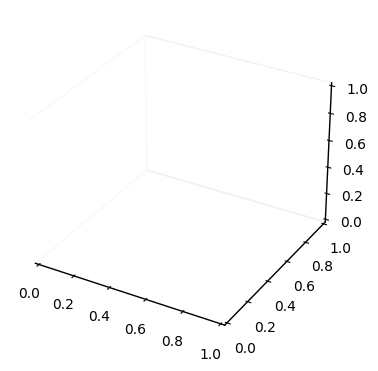

In [21]:
phi = np.linspace(0, 2*np.pi, 50)  # tune this to get a better resolution
x_circ = dim_koz[0,1] * np.sin(phi) 
y_circ = dim_koz[0,2] * np.cos(phi)

x_proj = -90
y_proj = -200
z_proj = 80

fig = plt.figure(figsize=(20,15))

for i in range(7): 
    
    print(f'Behavior {i} : {np.sum(behav==i)} samples')
    
    # collect samples
    rtn_cvx_i = rtn_cvx[behav==i]
    rtn_scp_i = rtn_scp[behav==i]    
    roe_cvx_i = roe_cvx[behav==i]
    roe_scp_i = roe_scp[behav==i]
    a_cvx_i   = a_cvx[behav==i]
    a_scp_i   = a_scp[behav==i]
    oe_i = oe[behav==i]
    wyp_i = wyp[behav==i]
    wyp_times_i = wyp_times[behav==i]
    
    ax_i = fig.add_subplot(2, 4, i+1, projection='3d')
    
    ax_i.set_facecolor('white')
    ax_i.grid(False)
    for axis in [ax_i.xaxis, ax_i.yaxis, ax_i.zaxis]:
        axis.pane.fill = False
        axis.line.set_color('black')
        axis.line.set_linewidth(1)  # increase thickness
    
    for j in range(np.min([rtn_scp_i.shape[0], 1])): 

        _, roe_cvx_ct_ij, rtn_cvx_ct_ij = propagate_ct(roe_cvx_i[j,:].T, a_cvx_i[j,:].T, oe_i[j,:].T, tvec_sec, n=10)
        _, roe_scp_ct_ij, rtn_scp_ct_ij = propagate_ct(roe_scp_i[j,:].T, a_scp_i[j,:].T, oe_i[j,:].T, tvec_sec, n=10)

        x_cvx, y_cvx, z_cvx = rtn_cvx_ct_ij[0], rtn_cvx_ct_ij[1], rtn_cvx_ct_ij[2]
        x_scp, y_scp, z_scp = rtn_scp_ct_ij[0], rtn_scp_ct_ij[1], rtn_scp_ct_ij[2]

        # x_cvx, y_cvx, z_cvx = rtn_cvx_i[i, :,0], rtn_cvx_i[i, :,1], rtn_cvx_i[i, :,2]
        # x_scp, y_scp, z_scp = rtn_scp_i[j,:,0], rtn_scp_i[j,:,1], rtn_scp_i[j,:,2]

        # plot trajectories (discrete-time)
        ax_i.plot(y_cvx, z_cvx, x_cvx, 'b--', zorder=5)
        ax_i.plot(y_scp, z_scp, x_scp, 'g-', zorder=5)
        ax_i.scatter([y_cvx[0]], [z_cvx[0]], [x_cvx[0]], c='red', marker='o', s=6)
        ax_i.scatter([y_cvx[-1]], [z_cvx[-1]], [x_cvx[-1]], c='orange', marker='o', s=6)
        plot_ellipse(ax_i, np.array([dim_koz[0,1], dim_koz[0,2], dim_koz[0,0]]), pos=[0,0,0], Ndisc=20)
        ax_i.scatter([0], [0], [0], c='red', marker='o', s=8)
        
        # scatter waypoints
        for k in range(wyp_i.shape[1]):
            wyp_rtn_i = roe_to_rtn(wyp_i[j, k], oe_i[j, wyp_times_i[j, k]])
            ax_i.scatter([wyp_rtn_i[1]], [wyp_rtn_i[2]], [wyp_rtn_i[0]], c='purple', marker='x', s=20, zorder=7)

        # minimal "projection shadows" onto planes
        alpha = 0.7
        ax_i.plot(y_scp, z_scp, np.full_like(x_scp, x_proj), 'k-', alpha=alpha, linewidth=0.5)  # xy plane (RT)
        ax_i.plot(y_scp, np.full_like(z_scp, z_proj), x_scp, 'k-', alpha=alpha, linewidth=0.5)  # xz plane (RN)
        ax_i.plot(np.full_like(y_scp, y_proj), z_scp, x_scp, 'k-', alpha=alpha, linewidth=0.5)  # yz plane (TN)

        # circle (kOZ) projection
        ax_i.plot(y_circ, x_circ, np.full_like(x_circ, x_proj), 'r-', alpha=alpha, linewidth=0.5)
        ax_i.plot(x_circ, np.full_like(x_circ, z_proj), y_circ, 'r-', alpha=alpha, linewidth=0.5)
        ax_i.plot(np.full_like(x_circ, y_proj), y_circ, x_circ, 'r-', alpha=alpha, linewidth=0.5)

    ax_i.set_title(f'Behavior: {i}')
    ax_i.set_xlabel('T [m]')
    ax_i.set_ylabel('N [m]')
    ax_i.set_zlabel('R [m]')
    # ax_i.axis("equal")

ax_i = fig.add_subplot(2, 4, 8, projection='3d')
ax_i.plot([],[], 'b-', label='trajectory (cvx)')
ax_i.plot([],[], 'g--', label='trajectory (scp)')
ax_i.scatter([],[], c='red', marker='o', label='Start')
ax_i.scatter([],[], c='orange', marker='o', label='Goal')
ax_i.legend()

fig.tight_layout()
